# Naive Bayes Classifier
### Reference: [GeeksForGeeks - Naive Bayes Classifiers](https://www.geeksforgeeks.org/naive-bayes-classifiers/)

---

## Table of Contents
1. [Definition](#1-definition)
2. [Bayes Theorem — The Math Foundation](#2-bayes-theorem)
3. [The Naive Assumption](#3-naive-assumption)
4. [Types of Naive Bayes](#4-types)
5. [Step-by-Step Worked Example](#5-worked-example)
6. [Laplace Smoothing — Solving Zero Probability](#6-laplace-smoothing)
7. [Advantages & Disadvantages](#7-advantages--disadvantages)
8. [Applications](#8-applications)
9. [From-Scratch Implementation](#9-from-scratch-implementation)
10. [Scikit-Learn Implementation](#10-scikit-learn-implementation)
11. [Text Classification with Naive Bayes](#11-text-classification)
12. [Summary](#12-summary)

---
## 1. Definition

**Naive Bayes** is a supervised machine learning **classification algorithm** that predicts the class of a data point using **probability theory** — specifically **Bayes' Theorem**.

### Why "Naive"?
It makes a **naive assumption** that all input features are **conditionally independent** of each other given the class label.

$$P(x_1, x_2, \ldots, x_n \mid y) = P(x_1 \mid y) \cdot P(x_2 \mid y) \cdots P(x_n \mid y)$$

This is rarely true in real data (e.g., the words "New" and "York" are correlated), but the algorithm still performs **surprisingly well** in practice.

### Key Characteristics

| Property | Value |
|---|---|
| Type | Supervised — Classification |
| Approach | Probabilistic (Bayesian) |
| Training | Fast — just compute statistics |
| Key Assumption | Feature independence given class |
| Best for | Text classification, high-dim data |
| Handles Multi-class | Yes (naturally) |

---
## 2. Bayes Theorem — The Math Foundation

### Bayes' Theorem

$$P(y \mid X) = \frac{P(X \mid y) \cdot P(y)}{P(X)}$$

### Terms Explained

| Term | Name | Meaning |
|---|---|---|
| $P(y \mid X)$ | **Posterior** | Probability of class y given features X — what we want to find |
| $P(X \mid y)$ | **Likelihood** | Probability of observing features X in class y |
| $P(y)$ | **Prior** | Overall probability of class y in training data |
| $P(X)$ | **Evidence** | Overall probability of features X — constant across classes |

### Simplified Decision Rule
Since $P(X)$ is the same for all classes, we compare:

$$\hat{y} = \arg\max_y \left[ P(y) \cdot \prod_{i=1}^{n} P(x_i \mid y) \right]$$

This is called **Maximum A Posteriori (MAP)** estimation.

### Log-Space for Numerical Stability
Multiplying many small probabilities leads to **numerical underflow**. We use log:

$$\hat{y} = \arg\max_y \left[ \log P(y) + \sum_{i=1}^{n} \log P(x_i \mid y) \right]$$

In [1]:
# Demonstrating Bayes' Theorem with a simple example
# Medical test: P(Disease) = 0.01, P(Positive|Disease) = 0.95, P(Positive|No Disease) = 0.05

P_disease   = 0.01              # Prior: 1% of people have the disease
P_no_dis    = 1 - P_disease     # Prior: 99% healthy
P_pos_given_dis    = 0.95       # Likelihood: test positive given disease
P_pos_given_no_dis = 0.05       # Likelihood: false positive rate

# Evidence: P(Positive)
P_positive = P_pos_given_dis * P_disease + P_pos_given_no_dis * P_no_dis

# Posterior: P(Disease | Positive)
P_disease_given_pos = (P_pos_given_dis * P_disease) / P_positive

print("=== Medical Test — Bayes Theorem ===")
print(f"Prior P(Disease)        = {P_disease:.2f} (1%)")
print(f"Likelihood P(+|Disease) = {P_pos_given_dis:.2f}")
print(f"Evidence P(+)           = {P_positive:.4f}")
print(f"Posterior P(Disease|+)  = {P_disease_given_pos:.4f} ({P_disease_given_pos*100:.2f}%)")
print()
print("Insight: Even with a 95% accurate test, if only 1% of people have the disease,")
print(f"a positive result means only {P_disease_given_pos*100:.1f}% chance of actually having it!")

=== Medical Test — Bayes Theorem ===
Prior P(Disease)        = 0.01 (1%)
Likelihood P(+|Disease) = 0.95
Evidence P(+)           = 0.0590
Posterior P(Disease|+)  = 0.1610 (16.10%)

Insight: Even with a 95% accurate test, if only 1% of people have the disease,
a positive result means only 16.1% chance of actually having it!


---
## 3. The Naive Assumption

### Without the Naive Assumption
Computing $P(X \mid y) = P(x_1, x_2, ..., x_n \mid y)$ requires estimating the **joint probability** of all features — exponentially complex.

### With the Naive Assumption (Feature Independence)
Assume each feature contributes **independently**:

$$P(X \mid y) = \prod_{i=1}^{n} P(x_i \mid y)$$

This makes computation **linear** in the number of features — fast and scalable.

### Why It Still Works
Even though features are not truly independent:
- The **relative ranking** of class probabilities is often preserved
- For **classification** (not probability estimation), we only need the correct ordering
- Works especially well in **text classification** where vocabulary is large

> **Analogy:** It's like asking "What's the weather today?" by checking temperature AND humidity **separately** instead of jointly — simpler model, still useful answer.

---
## 4. Types of Naive Bayes

The key difference between types is **how $P(x_i \mid y)$ is modeled**:

---

### 4.1 Gaussian Naive Bayes
- **Feature type:** Continuous / real-valued
- **Assumption:** Features follow a **Normal (Gaussian) distribution** within each class
- **Formula:**

$$P(x_i \mid y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma_y^2}\right)$$

Where $\mu_y$ = mean of feature $x_i$ for class $y$, and $\sigma_y^2$ = variance.

- **Use cases:** Iris classification, medical diagnosis, sensor data

---

### 4.2 Multinomial Naive Bayes
- **Feature type:** Discrete count data (word counts, term frequencies)
- **Assumption:** Features represent **frequency/count** of terms
- **Formula:**

$$P(x_i \mid y) = \frac{\text{count}(x_i, y) + \alpha}{\sum_j \text{count}(x_j, y) + \alpha \cdot |V|}$$

Where $\alpha$ is the Laplace smoothing parameter and $|V|$ is vocabulary size.

- **Use cases:** Spam filtering, document classification, sentiment analysis

---

### 4.3 Bernoulli Naive Bayes
- **Feature type:** Binary (0 or 1)
- **Assumption:** Each feature indicates **presence or absence** of a term
- **Formula:**

$$P(x_i \mid y) = P(i \mid y)^{x_i} \cdot (1 - P(i \mid y))^{(1-x_i)}$$

- **Use cases:** Binary text features, spam detection

---

### Choosing the Right Type

| Variant | Feature Type | Best For |
|---|---|---|
| **GaussianNB** | Continuous | Numeric/real-valued data |
| **MultinomialNB** | Count/frequency | Word counts, TF-IDF |
| **BernoulliNB** | Binary (0/1) | Word presence/absence |

---
## 5. Step-by-Step Worked Example

**Problem:** Predict if someone will **play golf** based on weather conditions.

**Training Data (14 days):**

| Day | Outlook | Temp | Humidity | Wind | Play? |
|---|---|---|---|---|---|
| 1 | Sunny | Hot | High | Weak | No |
| 2 | Sunny | Hot | High | Strong | No |
| 3 | Overcast | Hot | High | Weak | Yes |
| 4 | Rain | Mild | High | Weak | Yes |
| 5 | Rain | Cool | Normal | Weak | Yes |
| 6 | Rain | Cool | Normal | Strong | No |
| 7 | Overcast | Cool | Normal | Strong | Yes |
| 8 | Sunny | Mild | High | Weak | No |
| 9 | Sunny | Cool | Normal | Weak | Yes |
| 10 | Rain | Mild | Normal | Weak | Yes |
| 11 | Sunny | Mild | Normal | Strong | Yes |
| 12 | Overcast | Mild | High | Strong | Yes |
| 13 | Overcast | Hot | Normal | Weak | Yes |
| 14 | Rain | Mild | High | Strong | No |

**New Day:** Outlook=Sunny, Temp=Cool, Humidity=High, Wind=Strong

---

### Step 1: Prior Probabilities
$$P(\text{Yes}) = \frac{9}{14} \approx 0.643 \qquad P(\text{No}) = \frac{5}{14} \approx 0.357$$

### Step 2: Likelihood Probabilities
Count occurrences of each feature value within each class:

| Feature | Value | Count(Yes) | P(x|Yes) | Count(No) | P(x|No) |
|---|---|---|---|---|---|
| Outlook | Sunny | 2/9 | 0.222 | 3/5 | 0.600 |
| Temp | Cool | 3/9 | 0.333 | 1/5 | 0.200 |
| Humidity | High | 3/9 | 0.333 | 4/5 | 0.800 |
| Wind | Strong | 3/9 | 0.333 | 3/5 | 0.600 |

### Step 3: Apply Naive Bayes Formula
$$P(\text{Yes}|X) \propto P(\text{Yes}) \cdot P(\text{Sunny|Yes}) \cdot P(\text{Cool|Yes}) \cdot P(\text{High|Yes}) \cdot P(\text{Strong|Yes})$$
$$= 0.643 \times 0.222 \times 0.333 \times 0.333 \times 0.333 \approx 0.00528$$

$$P(\text{No}|X) \propto P(\text{No}) \cdot P(\text{Sunny|No}) \cdot P(\text{Cool|No}) \cdot P(\text{High|No}) \cdot P(\text{Strong|No})$$
$$= 0.357 \times 0.600 \times 0.200 \times 0.800 \times 0.600 \approx 0.02058$$

### Step 4: Normalize
$$P(\text{Yes}|X) = \frac{0.00528}{0.00528 + 0.02058} \approx 0.204 \quad (20.4\%)$$
$$P(\text{No}|X) = \frac{0.02058}{0.00528 + 0.02058} \approx 0.796 \quad (79.6\%)$$

### ❌ Prediction: NO — Do Not Play Golf

In [2]:
import numpy as np

# Golf dataset as conditional probabilities
# P(feature_value | class)

# Priors
P_yes = 9/14
P_no  = 5/14

# Likelihoods for new day: Outlook=Sunny, Temp=Cool, Humidity=High, Wind=Strong
likelihoods = {
    'Yes': {
        'Outlook=Sunny':  2/9,
        'Temp=Cool':      3/9,
        'Humidity=High':  3/9,
        'Wind=Strong':    3/9,
    },
    'No': {
        'Outlook=Sunny':  3/5,
        'Temp=Cool':      1/5,
        'Humidity=High':  4/5,
        'Wind=Strong':    3/5,
    }
}

print("=== Naive Bayes — Play Golf? ===")
print(f"New day: Outlook=Sunny, Temp=Cool, Humidity=High, Wind=Strong\n")
print(f"Prior P(Yes) = {P_yes:.4f}  |  P(No) = {P_no:.4f}\n")

# Compute unnormalized posteriors
scores = {}
for cls, prior in [('Yes', P_yes), ('No', P_no)]:
    score = prior
    print(f"--- Class: {cls} ---")
    print(f"  P({cls}) = {prior:.4f}")
    for feature, p in likelihoods[cls].items():
        print(f"  × P({feature}|{cls}) = {p:.4f}")
        score *= p
    print(f"  = {score:.6f}\n")
    scores[cls] = score

# Normalize
total = sum(scores.values())
print("=== Normalized Posterior ===")
for cls, s in scores.items():
    print(f"P({cls}|X) = {s/total:.4f}  ({s/total*100:.1f}%)")

prediction = max(scores, key=scores.get)
print(f"\nPrediction → {prediction}")

=== Naive Bayes — Play Golf? ===
New day: Outlook=Sunny, Temp=Cool, Humidity=High, Wind=Strong

Prior P(Yes) = 0.6429  |  P(No) = 0.3571

--- Class: Yes ---
  P(Yes) = 0.6429
  × P(Outlook=Sunny|Yes) = 0.2222
  × P(Temp=Cool|Yes) = 0.3333
  × P(Humidity=High|Yes) = 0.3333
  × P(Wind=Strong|Yes) = 0.3333
  = 0.005291

--- Class: No ---
  P(No) = 0.3571
  × P(Outlook=Sunny|No) = 0.6000
  × P(Temp=Cool|No) = 0.2000
  × P(Humidity=High|No) = 0.8000
  × P(Wind=Strong|No) = 0.6000
  = 0.020571

=== Normalized Posterior ===
P(Yes|X) = 0.2046  (20.5%)
P(No|X) = 0.7954  (79.5%)

Prediction → No


---
## 6. Laplace Smoothing — Solving the Zero Probability Problem

### The Problem
If a feature value **never appeared** with a class in training data:

$$P(x_i \mid y) = 0$$

This **zeroes out the entire posterior**, killing the prediction — even if all other features strongly indicate the class.

**Example:** "Free" never appeared in training ham emails → P(Free|Ham) = 0 → P(Ham|email) = 0 regardless of other words.

### The Solution: Laplace Smoothing (Add-α Smoothing)
Add a small constant $\alpha$ (usually $\alpha=1$) to all feature counts:

$$P(x_i \mid y) = \frac{\text{count}(x_i, y) + \alpha}{\text{count}(y) + \alpha \cdot |V|}$$

Where $|V|$ is the number of distinct feature values (vocabulary size).

**Effect:** No probability is ever exactly 0. Unseen values get a small but nonzero probability.

In [3]:
# Laplace Smoothing demonstration
import numpy as np

# Suppose 'Rainy' never appears with class 'Yes' in training (count=0)
count_rainy_yes = 0
count_yes       = 9
V               = 3  # vocabulary size for Outlook: Sunny, Overcast, Rainy
alpha           = 1  # Laplace smoothing parameter

# Without smoothing
p_no_smooth = count_rainy_yes / count_yes

# With Laplace smoothing
p_smooth    = (count_rainy_yes + alpha) / (count_yes + alpha * V)

print("=== Laplace Smoothing ===")
print(f"count(Rainy|Yes) = {count_rainy_yes}")
print(f"count(Yes)       = {count_yes}")
print(f"Vocabulary size  = {V}")
print()
print(f"Without smoothing: P(Rainy|Yes) = {count_rainy_yes}/{count_yes} = {p_no_smooth}")
print(f"  → This ZEROES OUT the entire posterior!")
print()
print(f"With smoothing (α={alpha}): P(Rainy|Yes) = ({count_rainy_yes}+{alpha}) / ({count_yes}+{alpha}×{V})")
print(f"  = {count_rainy_yes+alpha} / {count_yes + alpha*V} = {p_smooth:.4f}")
print(f"  → Small but nonzero probability ✓")

=== Laplace Smoothing ===
count(Rainy|Yes) = 0
count(Yes)       = 9
Vocabulary size  = 3

Without smoothing: P(Rainy|Yes) = 0/9 = 0.0
  → This ZEROES OUT the entire posterior!

With smoothing (α=1): P(Rainy|Yes) = (0+1) / (9+1×3)
  = 1 / 12 = 0.0833
  → Small but nonzero probability ✓


---
## 7. Advantages & Disadvantages

### ✅ Advantages

| Advantage | Explanation |
|---|---|
| Fast Training | Just computes statistics (counts, means, variances) |
| Fast Prediction | Simple arithmetic — scales to huge datasets |
| Works with Small Data | Needs fewer examples than complex models |
| Handles High Dimensions | Excellent for NLP (thousands of features) |
| Multi-class Native | No modification needed for multiple classes |
| Strong Baseline | Often beats complex models on text tasks |
| Online Learning | Can update probabilities incrementally with new data |

### ❌ Disadvantages

| Disadvantage | Explanation |
|---|---|
| Independence Assumption | Features are rarely truly independent in real data |
| Zero Probability | Unseen feature values kill the posterior (solved by Laplace smoothing) |
| Poor Probability Estimates | Predicted probabilities are poorly calibrated |
| Sensitive to Feature Correlations | Correlated features are double-counted |
| Gaussian Assumption May Not Fit | GaussianNB assumes normal distribution within each class |

---
## 8. Applications

| Domain | Application |
|---|---|
| Email | Spam filtering — classify spam vs ham |
| NLP | Sentiment analysis, document classification |
| Healthcare | Medical diagnosis from symptoms |
| Finance | Credit scoring, fraud detection |
| News | Automatic topic categorization |
| Social Media | Hate speech / toxicity detection |
| Recommendation | Content-based filtering |

---
## 9. From-Scratch Implementation

In [4]:
import numpy as np

class GaussianNaiveBayes:
    """
    Gaussian Naive Bayes Classifier — from scratch.
    Assumes features follow a Gaussian distribution within each class.
    """

    def fit(self, X, y):
        X, y = np.array(X, dtype=float), np.array(y)
        self.classes = np.unique(y)
        self.priors  = {}   # P(y)
        self.means   = {}   # mu per class per feature
        self.vars    = {}   # sigma^2 per class per feature

        for c in self.classes:
            X_c = X[y == c]
            self.priors[c] = X_c.shape[0] / X.shape[0]
            self.means[c]  = X_c.mean(axis=0)
            self.vars[c]   = X_c.var(axis=0) + 1e-9  # tiny epsilon for stability

        return self

    def _log_likelihood(self, x, c):
        # log P(x_i | y=c) for Gaussian: uses log of Gaussian PDF
        mu  = self.means[c]
        var = self.vars[c]
        return -0.5 * np.sum(np.log(2 * np.pi * var) + ((x - mu)**2 / var))

    def _predict_one(self, x):
        log_posteriors = {}
        for c in self.classes:
            log_posteriors[c] = np.log(self.priors[c]) + self._log_likelihood(x, c)
        return max(log_posteriors, key=log_posteriors.get)

    def predict(self, X):
        return np.array([self._predict_one(x) for x in np.array(X, dtype=float)])

    def score(self, X, y):
        return np.mean(self.predict(X) == np.array(y))


# Test on Iris dataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gnb = GaussianNaiveBayes()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)
print("=== Gaussian Naive Bayes (from scratch) on Iris ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nPer-class Statistics:")
for c in gnb.classes:
    print(f"  Class {c}: prior={gnb.priors[c]:.3f}  | means={gnb.means[c].round(2)}")

=== Gaussian Naive Bayes (from scratch) on Iris ===
Accuracy: 1.0000

Per-class Statistics:
  Class 0: prior=0.333  | means=[4.99 3.45 1.45 0.24]
  Class 1: prior=0.342  | means=[5.92 2.77 4.24 1.32]
  Class 2: prior=0.325  | means=[6.53 2.97 5.52 2.  ]


---
## 10. Scikit-Learn Implementation

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# ─── Gaussian Naive Bayes on Iris ────────────────────────────────────────────
data = load_iris()
X, y = data.data, data.target
target_names = data.target_names

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Classes: {target_names}")
print(f"Distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

Dataset: 150 samples, 4 features
Classes: ['setosa' 'versicolor' 'virginica']
Distribution: {0: 50, 1: 50, 2: 50}


Test Accuracy: 0.9667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



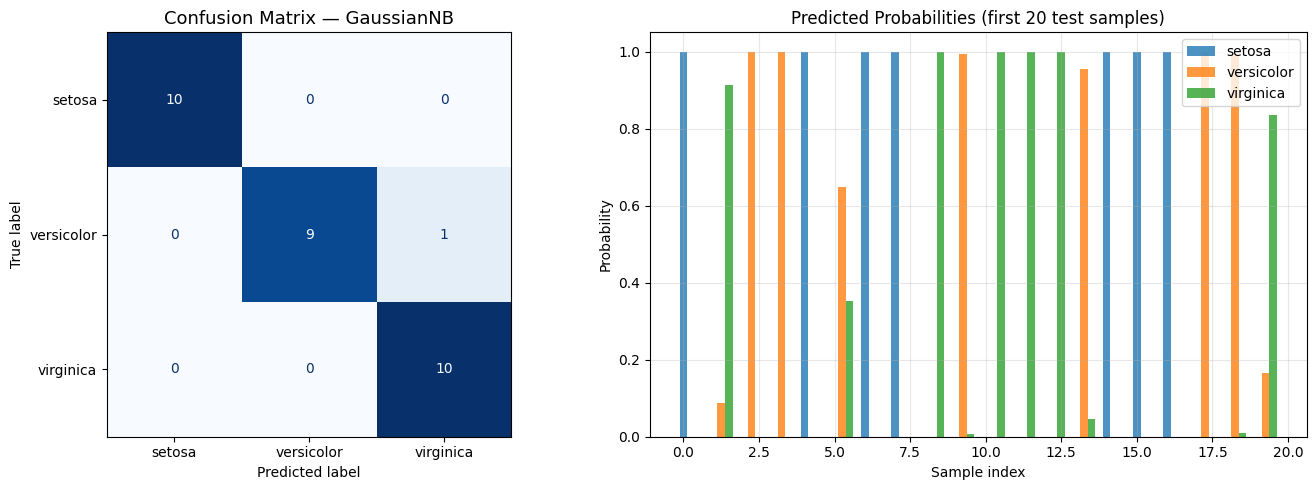

In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Gaussian NB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred  = gnb.predict(X_test)
y_proba = gnb.predict_proba(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — GaussianNB', fontsize=13)

# Probability distribution for first 20 test samples
x = np.arange(20)
width = 0.25
for i, name in enumerate(target_names):
    axes[1].bar(x + i*width, y_proba[:20, i], width, label=name, alpha=0.8)
axes[1].set_title('Predicted Probabilities (first 20 test samples)', fontsize=12)
axes[1].set_xlabel('Sample index'); axes[1].set_ylabel('Probability')
axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [7]:
# Cross-validation comparison across all NB variants
import numpy as np
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler required for Bernoulli (binary-ish features)
X_scaled = MinMaxScaler().fit_transform(X)

models = {
    'GaussianNB':   (GaussianNB(),   X),
    'BernoulliNB':  (BernoulliNB(),  X_scaled),
}

print("=== Cross-Validation Comparison ===")
for name, (model, Xd) in models.items():
    scores = cross_val_score(model, Xd, y, cv=10, scoring='accuracy')
    print(f"{name:18s}: mean={scores.mean():.4f}  std={scores.std():.4f}")

=== Cross-Validation Comparison ===
GaussianNB        : mean=0.9533  std=0.0427
BernoulliNB       : mean=0.3667  std=0.0447


---
## 11. Text Classification with Naive Bayes

In [8]:
# ─── Spam Detection with Multinomial NB ──────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Simple spam/ham dataset
emails = [
    # SPAM
    "FREE money win prize cash lottery",
    "Click here to claim your FREE reward NOW",
    "Win a million dollars lottery prize winner",
    "Urgent cash prize winner claim now free offer",
    "Buy cheap pills online no prescription free delivery",
    "Make money fast free home business opportunity",
    "You are selected winner free prize money reward",
    "Limited time offer buy now discount free gift",
    # HAM
    "Meeting scheduled for tomorrow afternoon",
    "Can you send me the project report please",
    "Lunch at noon today sounds good",
    "Please review the attached document",
    "Happy birthday hope you have a great day",
    "The conference call is at 3pm today",
    "Thank you for your help with the presentation",
    "Let me know when you are available to talk",
]
labels = [1,1,1,1,1,1,1,1,  0,0,0,0,0,0,0,0]  # 1=spam, 0=ham

X_train_txt, X_test_txt, y_train_txt, y_test_txt = train_test_split(
    emails, labels, test_size=0.25, random_state=42, stratify=labels
)

# CountVectorizer converts text to word count matrix
vectorizer = CountVectorizer()
X_tr = vectorizer.fit_transform(X_train_txt)
X_te = vectorizer.transform(X_test_txt)

print(f"Vocabulary size: {len(vectorizer.vocabulary_)} words")
print(f"Feature matrix shape: {X_tr.shape}\n")

# Train MultinomialNB with Laplace smoothing (alpha=1)
mnb = MultinomialNB(alpha=1.0)  # alpha = Laplace smoothing
mnb.fit(X_tr, y_train_txt)

y_pred_txt = mnb.predict(X_te)
print(f"MultinomialNB Accuracy: {accuracy_score(y_test_txt, y_pred_txt):.4f}")
print(classification_report(y_test_txt, y_pred_txt, target_names=['Ham','Spam']))

Vocabulary size: 65 words
Feature matrix shape: (12, 65)

MultinomialNB Accuracy: 1.0000
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00         2
        Spam       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [9]:
# Predict new emails
new_emails = [
    "FREE lottery winner claim your prize money NOW",
    "See you at the meeting tomorrow at 2pm",
    "Win cash prize click here free offer today",
    "Can we reschedule the project review call"
]

X_new = vectorizer.transform(new_emails)
preds   = mnb.predict(X_new)
probas  = mnb.predict_proba(X_new)

print("=== Predicting New Emails ===")
for email, pred, proba in zip(new_emails, preds, probas):
    label = 'SPAM' if pred == 1 else 'HAM'
    print(f"[{label}] (ham={proba[0]:.2f}, spam={proba[1]:.2f})")
    print(f"  '{email}'\n")

=== Predicting New Emails ===
[SPAM] (ham=0.00, spam=1.00)
  'FREE lottery winner claim your prize money NOW'

[HAM] (ham=1.00, spam=0.00)
  'See you at the meeting tomorrow at 2pm'

[SPAM] (ham=0.00, spam=1.00)
  'Win cash prize click here free offer today'

[HAM] (ham=0.96, spam=0.04)
  'Can we reschedule the project review call'



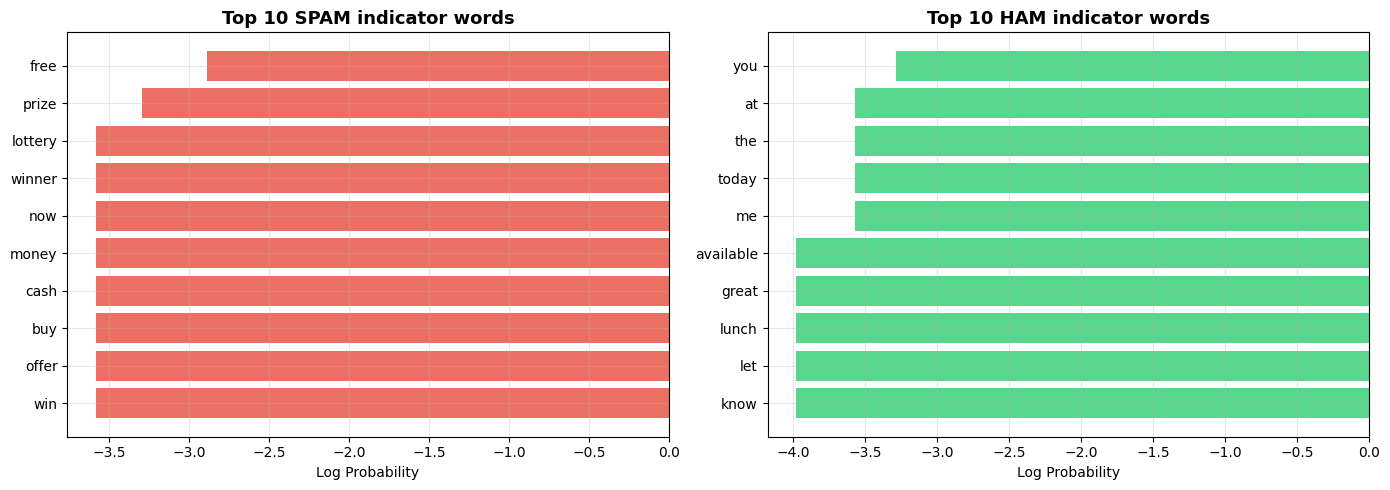

In [10]:
# Visualize top spam/ham words by log probability
import matplotlib.pyplot as plt
import numpy as np

feature_names = np.array(vectorizer.get_feature_names_out())
ham_log_prob  = mnb.feature_log_prob_[0]
spam_log_prob = mnb.feature_log_prob_[1]

# Top 10 spam indicators
top_spam_idx = np.argsort(spam_log_prob)[-10:]
top_ham_idx  = np.argsort(ham_log_prob)[-10:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(feature_names[top_spam_idx], spam_log_prob[top_spam_idx], color='#e74c3c', alpha=0.8)
axes[0].set_title('Top 10 SPAM indicator words', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Log Probability')
axes[0].grid(alpha=0.3)

axes[1].barh(feature_names[top_ham_idx], ham_log_prob[top_ham_idx], color='#2ecc71', alpha=0.8)
axes[1].set_title('Top 10 HAM indicator words', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Log Probability')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Bernoulli NB — Binary features (word presence/absence)
from sklearn.naive_bayes import BernoulliNB
from sklearn.feature_extraction.text import CountVectorizer

# binary=True converts counts to 0/1
bin_vec = CountVectorizer(binary=True)
X_tr_b  = bin_vec.fit_transform(X_train_txt)
X_te_b  = bin_vec.transform(X_test_txt)

bnb = BernoulliNB(alpha=1.0)
bnb.fit(X_tr_b, y_train_txt)

print(f"BernoulliNB Accuracy: {accuracy_score(y_test_txt, bnb.predict(X_te_b)):.4f}")
print("\nDifference: MultinomialNB uses word counts; BernoulliNB uses word presence only.")

BernoulliNB Accuracy: 1.0000

Difference: MultinomialNB uses word counts; BernoulliNB uses word presence only.


---
## 12. Summary

### Naive Bayes at a Glance

| Property | Detail |
|---|---|
| Full Name | Naive Bayes Classifier |
| Type | Supervised — Classification |
| Approach | Probabilistic (Bayesian) |
| Key Assumption | Feature independence given class |
| Training Time | O(n·d) — very fast |
| Prediction Time | O(d·c) — d=features, c=classes |
| Feature Scaling | Not required |
| Missing Values | Handled naturally |
| Multi-class | Yes (native) |
| Zero Probability | Fixed with Laplace smoothing |

### When to Use Naive Bayes

| Situation | Recommendation |
|---|---|
| Text classification | ✅ Excellent choice |
| Large feature space | ✅ Scales well |
| Fast training needed | ✅ Fastest classifier |
| Small dataset | ✅ Works with fewer samples |
| Need accurate probabilities | ❌ Poorly calibrated |
| Features are highly correlated | ❌ Assumption violated |

### Choosing the Right Variant

| Variant | sklearn Class | Feature Type | Example |
|---|---|---|---|
| Gaussian | `GaussianNB()` | Continuous | Iris, medical data |
| Multinomial | `MultinomialNB(alpha=1)` | Count/frequency | Word counts, TF-IDF |
| Bernoulli | `BernoulliNB(alpha=1)` | Binary (0/1) | Word presence |

### Sklearn Cheat Sheet
```python
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

# Gaussian — for continuous features
GaussianNB(var_smoothing=1e-9)  # var_smoothing: numerical stability

# Multinomial — for word counts
MultinomialNB(alpha=1.0)        # alpha: Laplace smoothing

# Bernoulli — for binary features
BernoulliNB(alpha=1.0)          # alpha: Laplace smoothing
```

---
> **Reference:** [GeeksForGeeks — Naive Bayes Classifiers](https://www.geeksforgeeks.org/naive-bayes-classifiers/)

- Gaussian - https://www.geeksforgeeks.org/machine-learning/gaussian-naive-bayes/m
- multinomial - https://www.geeksforgeeks.org/machine-learning/multinomial-naive-bayes/
- bernouli - https://www.geeksforgeeks.org/machine-learning/bernoulli-naive-bayes/